<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Corporate_Financial_Health%2C_Operational_Performance_%26_Stock_Forecasting_Analytics_using_Machine_Learning_and_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA

In [3]:
ticker = 'MS'

stock = yf.download(
    ticker,
    start = '2020-01-01',
    end = '2026-05-01'
)

[*********************100%***********************]  1 of 1 completed


In [4]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,MS,MS,MS,MS,MS
Date,,,,,
2020-01-02,42.604599,42.620973,41.892337,41.916900,7808000
2020-01-03,41.916920,42.121592,41.614005,41.933294,6706000
2020-01-06,41.769550,41.785924,41.311083,41.483007,7476700
2020-01-07,41.687683,41.908730,41.515759,41.785928,4538100
2020-01-08,42.219826,42.399938,41.671305,41.720425,6185200


In [5]:
np.random.seed(42)

finance = pd.DataFrame({
    'Revenue':np.random.randint(
        35000,
        70000,
        1000
    ),

    'Operating Expenses':np.random.randint(
        15000,
        45000,
        1000
    ),

    'Net Income':np.random.randint(
        4000,
        18000,
        1000
    ),

    'Assets':np.random.randint(
        250000,
        450000,
        1000
    ),

    'Liabilities':np.random.randint(
        120000,
        450000,
        1000
    ),

    'Operating Cash Flow':np.random.randint(
        7000,
        30000,
        1000
    )
})

In [6]:
finance['Profit Margin'] = (
    finance['Net Income']
    /
    finance['Revenue']
)

In [7]:
#DEBT RATIO

finance['Debt Ratio'] = (
    finance['Liabilities']
    /
    finance['Assets']
)

In [8]:
#Return On Assets

finance['ROA'] = (
    finance['Net Income']
    /
    finance['Assets']
)

In [9]:
#Efficiency Ratio

finance['Efficiency Ratio'] = (
    finance['Operating Expenses']
    /
    finance['Revenue']
)

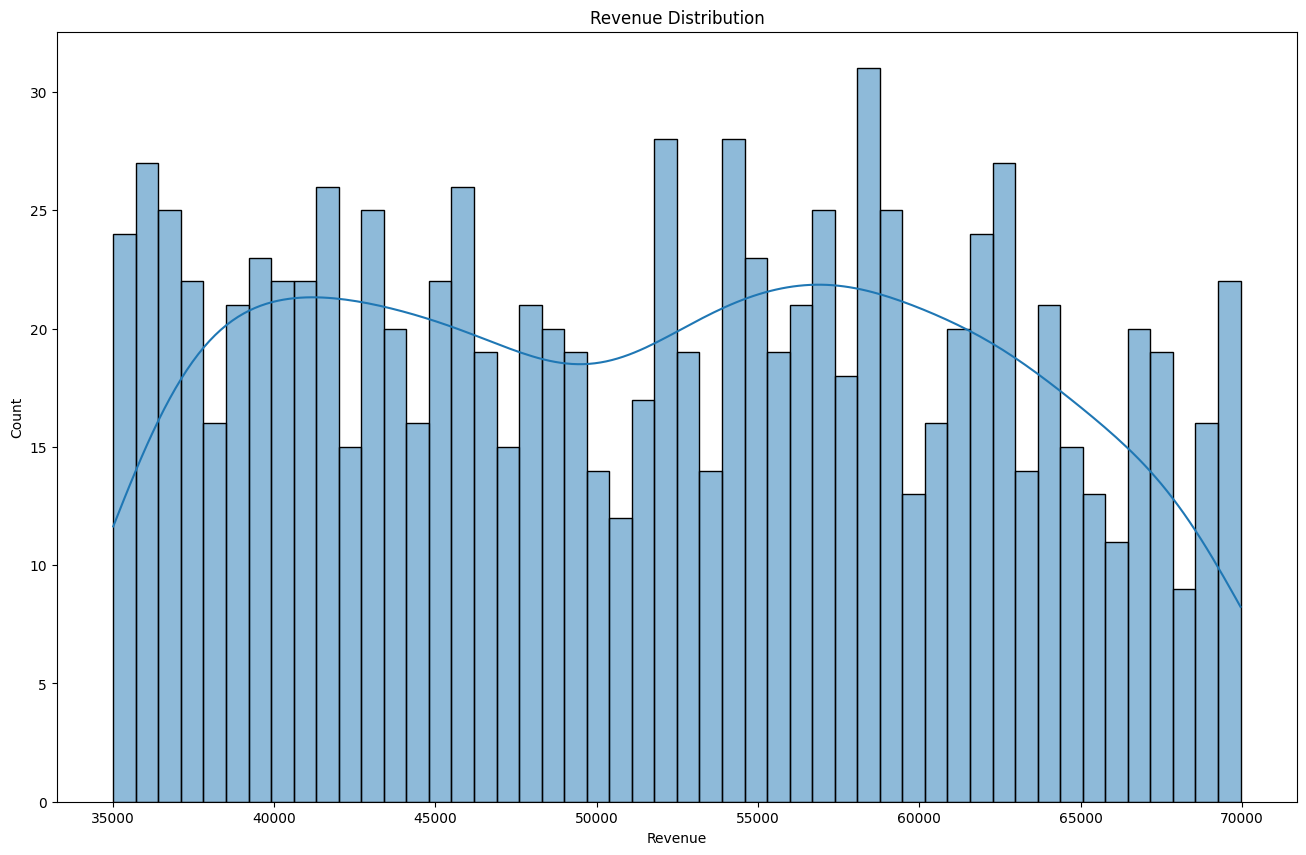

In [10]:
#REVENUE DISTRIBUTION

plt.figure(figsize=(16,10))

sns.histplot(
    finance['Revenue'],
    bins=50,
    kde=True
)

plt.title('Revenue Distribution')
plt.show()

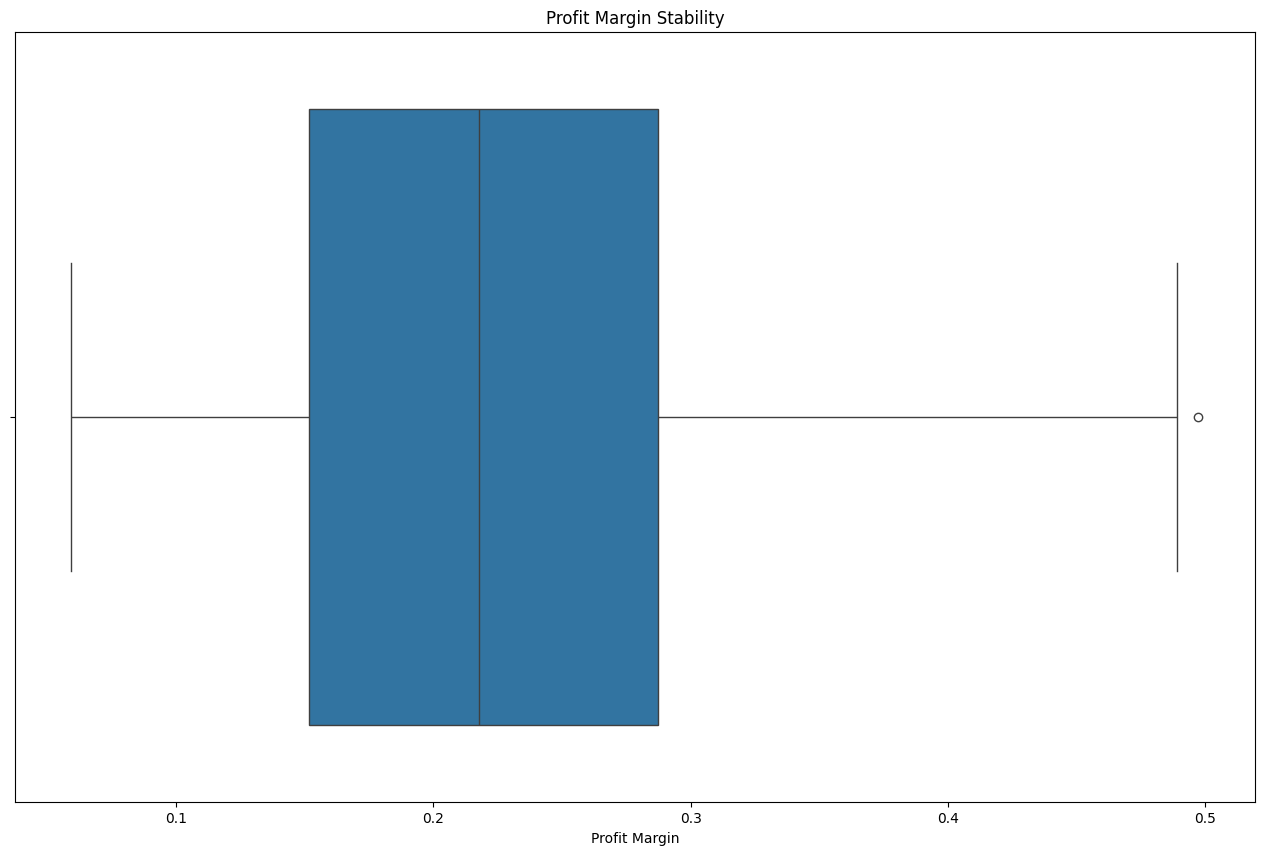

In [11]:
plt.figure(figsize=(16,10))

sns.boxplot(
    x = finance['Profit Margin']
)

plt.title('Profit Margin Stability')
plt.show()

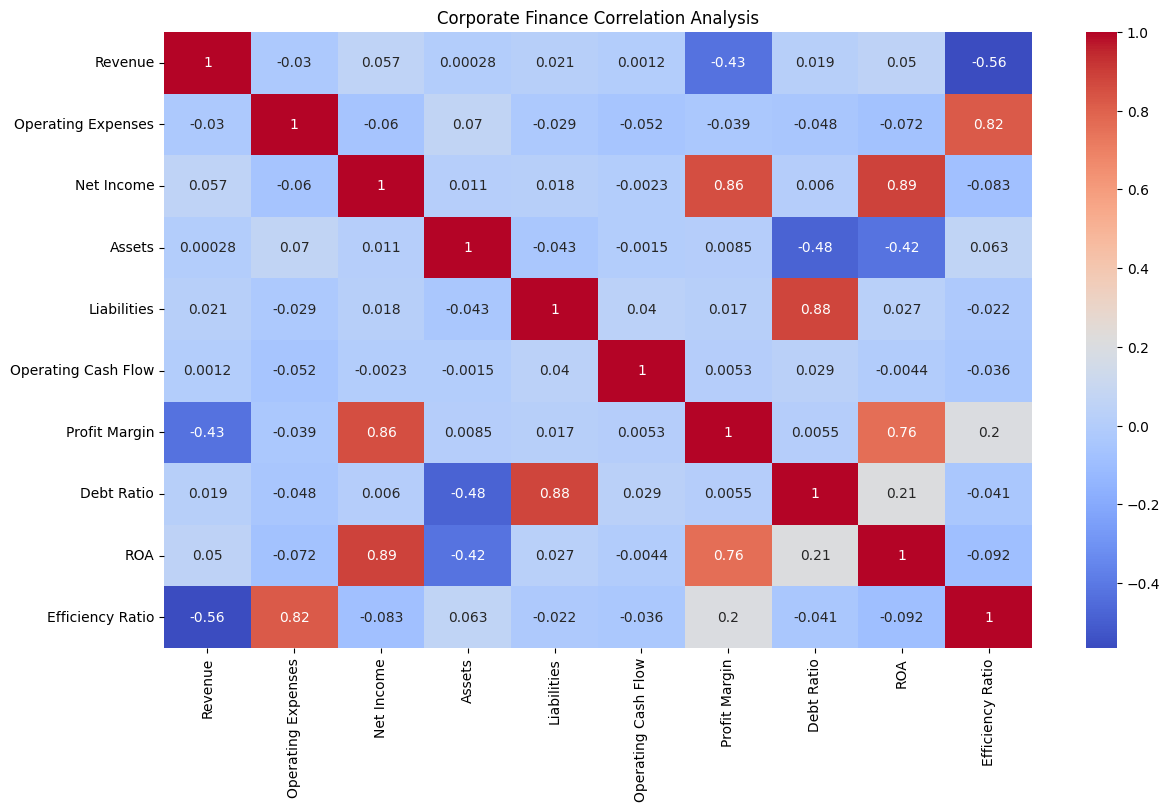

In [12]:
plt.figure(figsize=(14,8))

sns.heatmap(finance.corr(),annot=True,cmap='coolwarm')

plt.title('Corporate Finance Correlation Analysis')
plt.show()

#STOCK MARKET ANALYSIS

In [13]:
#Daily Returns

stock['Daily_Return'] = (
    stock['Close']
    .pct_change()
)

In [14]:
stock['Volatility'] = (
    stock['Daily_Return']
    .rolling(30)
    .std()
)

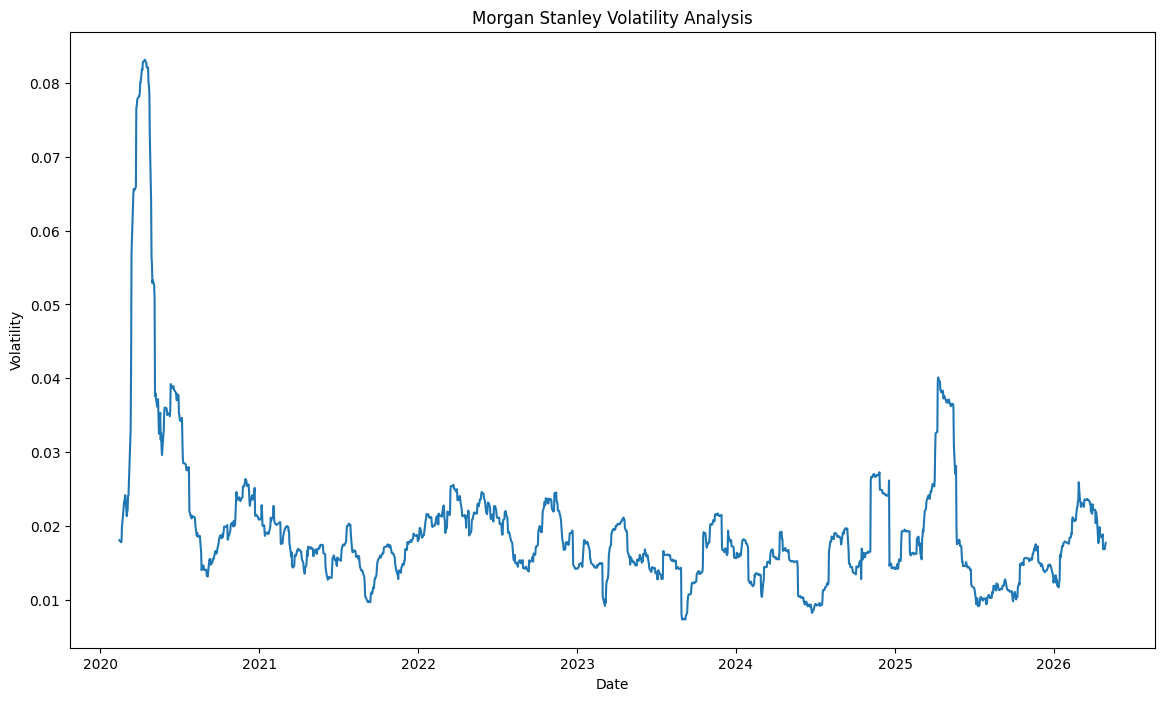

In [15]:
plt.figure(figsize=(14,8))

sns.lineplot(
    x=stock.index,
    y=stock['Volatility']
)

plt.title('Morgan Stanley Volatility Analysis')
plt.show()

In [18]:
features = [

    'Revenue',

    'Operating Expenses',

    'Assets',

    'Liabilities',

    'Operating Cash Flow'
]

X = finance[features]

y = finance['Net Income']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

In [21]:
lr_pred = lr.predict(X_test)

In [22]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [24]:
rf_pred = rf.predict(X_test)

In [25]:
xgb = XGBRegressor(
    n_estimatore=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimatore=500,
             n_estimators=None, n_jobs=None, ...)

In [26]:
xgb_pred = xgb.predict(X_test)

In [29]:
def evaluate(y_true, pred, model):

    print(f"\n{model}")

    print(
        "MAE:",
        mean_absolute_error(y_true, pred)
    )

    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, pred))
    )

    print(
        "R2:",
        r2_score(y_true, pred)
    )

In [30]:
evaluate(y_test, lr_pred, 'Linear Regression')

evaluate(y_test, rf_pred, 'Random Forest')

evaluate(y_test, xgb_pred, 'XGBoost')


Linear Regression
MAE: 3395.105937660412
RMSE: 3939.2245072806727
R2: -0.013112571525431882

Random Forest
MAE: 3380.4905
RMSE: 4009.597579433128
R2: -0.049633812428478974

XGBoost
MAE: 3457.691650390625
RMSE: 4068.8366887846455
R2: -0.08087813854217529


In [31]:
importance = pd.DataFrame({
    'Feature':features,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

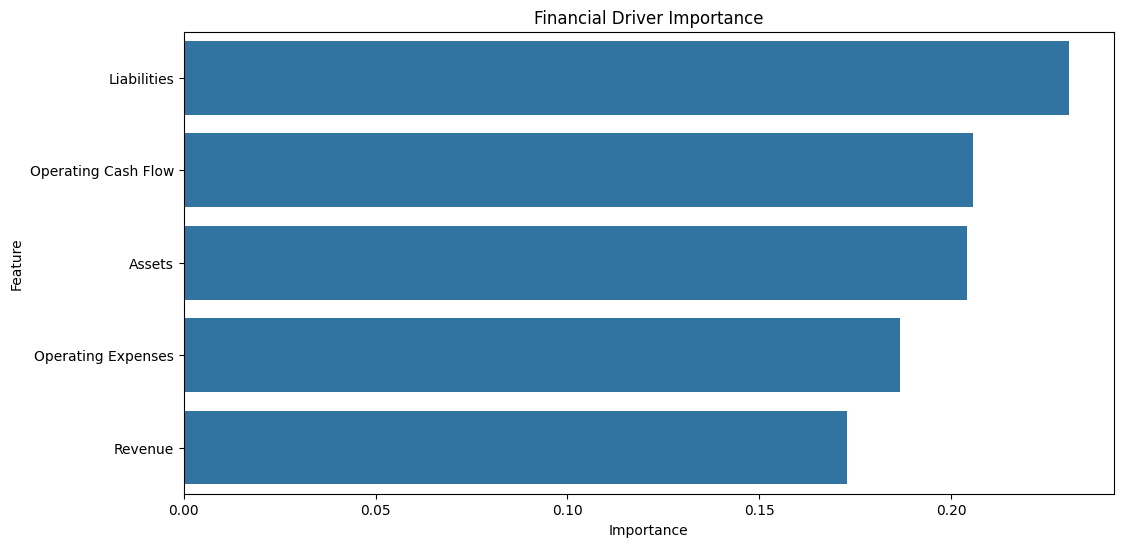

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Financial Driver Importance')

plt.show()

In [33]:
close_price = stock['Close'].dropna()

In [34]:
model = ARIMA(
    close_price,
    order=(5,1,0)
)

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [35]:
forecast = model_fit.forecast(
    steps=30
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


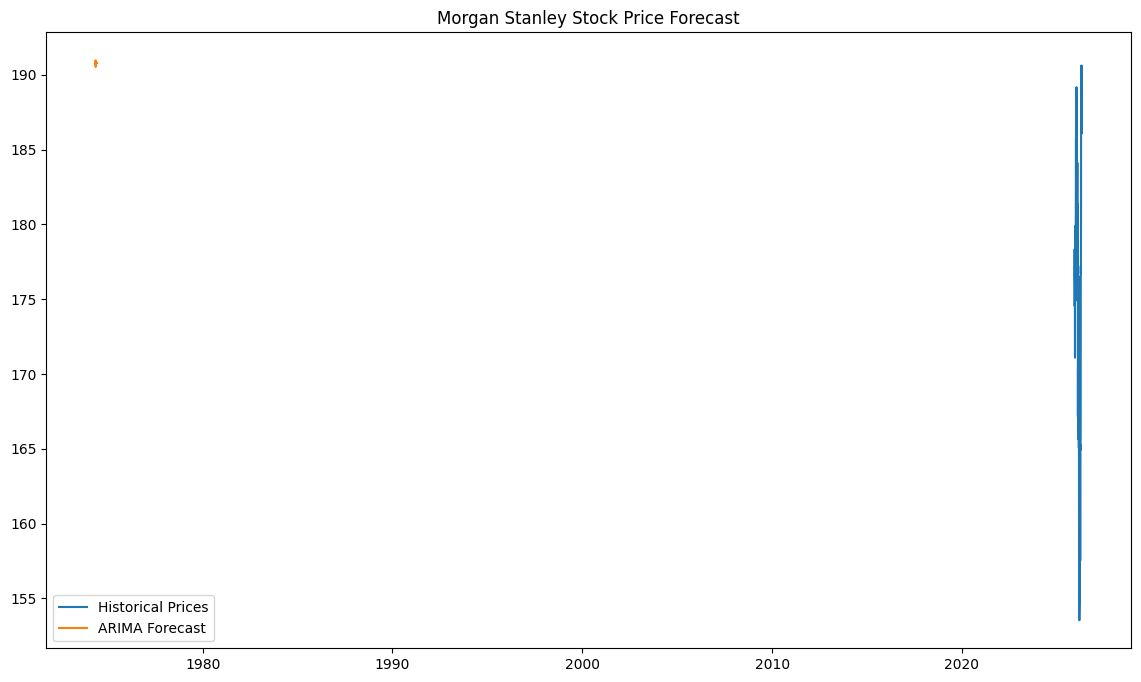

In [36]:
plt.figure(figsize=(14,8))

plt.plot(
    close_price[-100:],
    label='Historical Prices'
)

plt.plot(
    forecast,
    label='ARIMA Forecast'
)

plt.legend()
plt.title('Morgan Stanley Stock Price Forecast')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


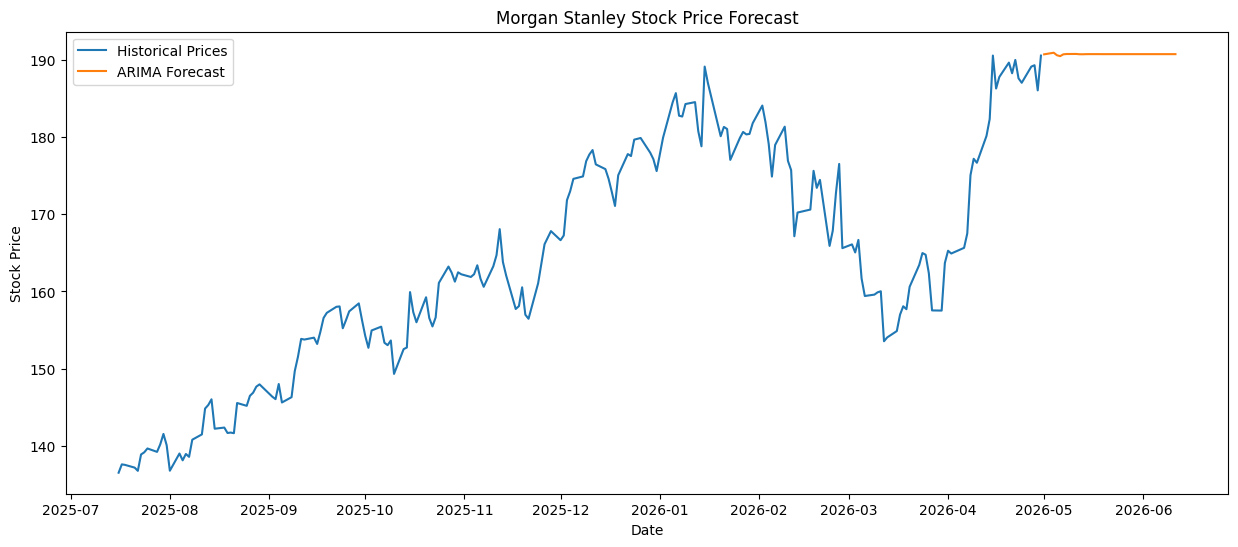

In [37]:
from pandas.tseries.offsets import BDay

close_prices = stock['Close'].dropna()

# Build model
model = ARIMA(close_prices, order=(5,1,0))

model_fit = model.fit()

# Forecast next 30 business days
forecast = model_fit.forecast(steps=30)

# Create future dates
future_dates = pd.date_range(
    start=close_prices.index[-1] + BDay(1),
    periods=30,
    freq='B'
)

forecast_series = pd.Series(
    forecast.values,
    index=future_dates
)

# Plot
plt.figure(figsize=(15,6))

plt.plot(
    close_prices[-200:],
    label='Historical Prices'
)

plt.plot(
    forecast_series,
    label='ARIMA Forecast'
)

plt.title('Morgan Stanley Stock Price Forecast')

plt.xlabel('Date')

plt.ylabel('Stock Price')

plt.legend()

plt.show()

The machine learning models demonstrated weak predictive performance in forecasting Morgan Stanley’s profitability and operational performance, as reflected by the negative R² scores for Linear Regression, Random Forest, and XGBoost, indicating that the selected financial variables were insufficient to accurately explain the target behavior. This outcome highlights a key financial analytics insight that financial systems are highly complex, noisy, and influenced by multiple external factors such as interest rates, macroeconomic conditions, investor sentiment, market volatility, and business cycles, making accurate forecasting challenging. The poor performance of advanced models further suggests that model complexity alone cannot compensate for weak feature relationships or unrealistic financial dependencies within the dataset, emphasizing the importance of high-quality data and meaningful feature engineering in financial analytics. Meanwhile, the ARIMA model successfully captured sequential time-series behavior and short-term momentum patterns in Morgan Stanley’s stock prices, demonstrating how historical market trends can be used for financial forecasting and volatility analysis. Overall, the project provided valuable understanding of corporate financial health, operational efficiency, profitability drivers, market behavior, and the practical challenges involved in applying machine learning to real-world financial analytics problems.